In [36]:
from scipy.ndimage import gaussian_filter1d

import cns
import cns.data_utils as cdu
import numpy as np
import matplotlib.pyplot as plt

In [37]:
samples_df, cns_df = cdu.main_load("3MB")

In [38]:
lusc_group_df = cns.group_samples(cns.add_total_cn(cns.select_cns_by_type(cns_df, samples_df, "LUSC")))
chr3_group_df = cns.only_aut(lusc_group_df).query("chrom == 'chr3'")
chr3_group_df["cum_mid"] = cns.calc_cum_mid(chr3_group_df)
chr3_group_df["is_count"] = (chr3_group_df["start"] - chr3_group_df["end"].shift(1) == 0) & (chr3_group_df["end"] - chr3_group_df["start"].shift(-1) == 0)
chr3_group_df.head()


,chrom,start,end,name,major_cn,minor_cn,total_cn,sample_id,cum_mid,is_count
518,chr3,0,3016828,chr3_0_0,1.858404,0.137451,1.995855,grouped,493958408,False
519,chr3,3016828,6033657,chr3_0_1,1.866199,0.137101,2.003300,grouped,496975236,True
520,chr3,6033657,9050485,chr3_0_2,1.874999,0.135743,2.010742,grouped,499992065,True
521,chr3,9050485,12067314,chr3_0_3,1.866560,0.133706,2.000266,grouped,503008893,True
522,chr3,12067314,15084142,chr3_0_4,1.850256,0.130281,1.980537,grouped,506025722,True


In [39]:
def get_grads(signal, cn_col, smoothing=0):
    first_derivative = np.gradient(signal[cn_col])
    second_derivative = np.gradient(first_derivative)
    # multiply by 0 where start and end don't match
    continuous_der = second_derivative * signal["is_count"].astype(int)
    return continuous_der

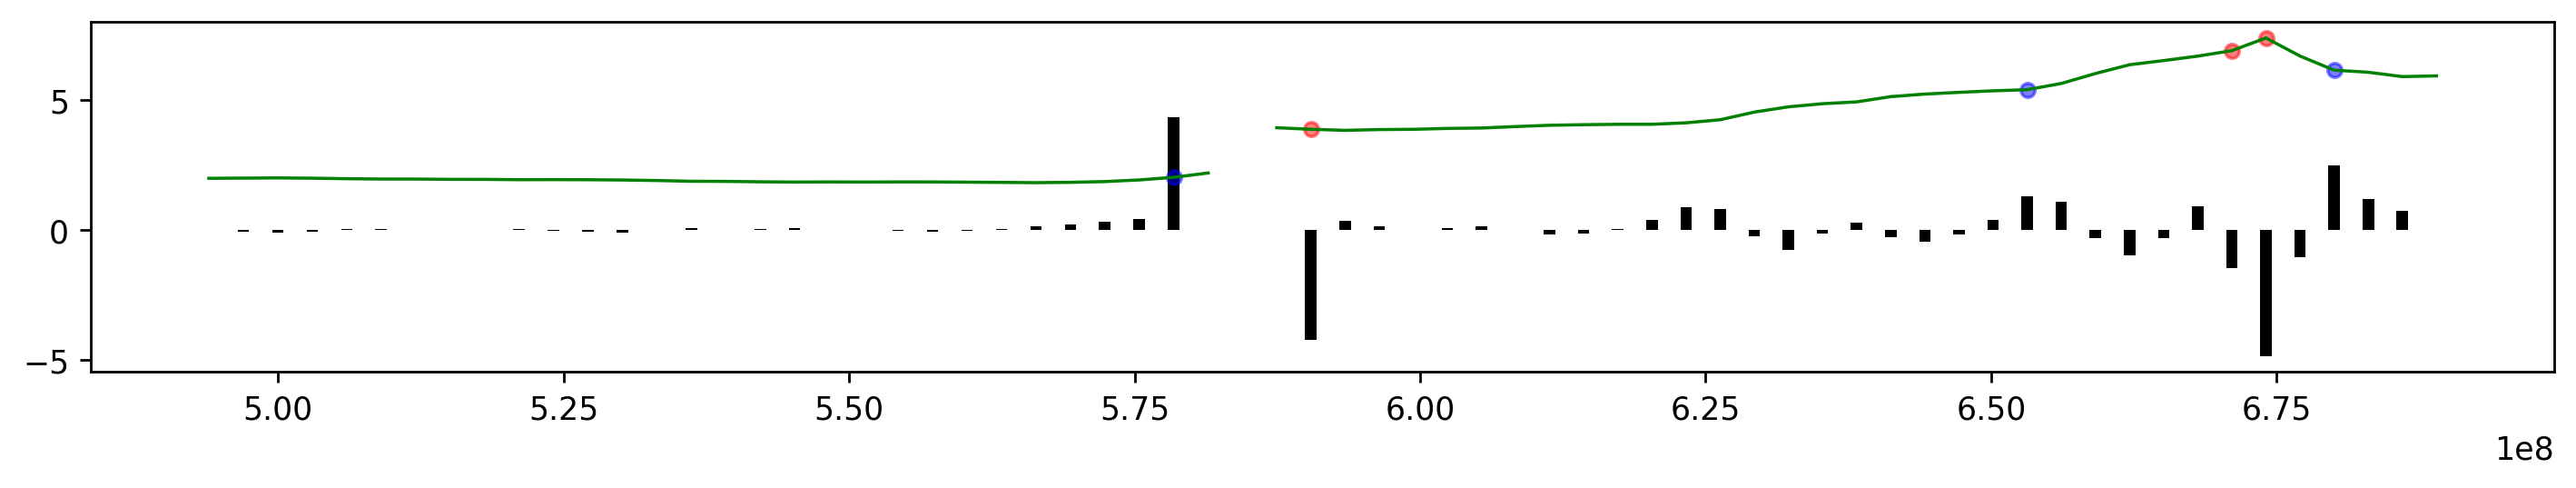

In [40]:
is_consecutive = chr3_group_df["start"] - chr3_group_df["end"].shift(1) != 0
# plot consecutive segments
for i, group_df in chr3_group_df.groupby(is_consecutive.cumsum()):
    # calculate gaussian smoothing of total_cn
    chr3_group_df.loc[group_df.index, "total_cn_smooth"] = gaussian_filter1d(group_df["total_cn"], sigma=1)
chr3_group_df

val_count = 3
con_der = get_grads(chr3_group_df, "total_cn")
# indices of top 5 values
top_vals = np.argsort(con_der)[:val_count]
bot_vals = np.argsort(con_der)[-val_count:]

fig, ax = plt.subplots(figsize=(14, 2), dpi=250)

cns.plot_lines(ax, chr3_group_df, cn_column="total_cn")
# bar plot con_der
ax.bar(chr3_group_df["cum_mid"], con_der * 10, width=1000000, color="black")
# cns.plot_lines(ax, chr3_group_df, cn_column="total_cn_smooth", color="black")

ax.scatter(chr3_group_df["cum_mid"].iloc[top_vals], chr3_group_df["total_cn"].iloc[top_vals], color='red', alpha=0.5, s=20)
ax.scatter(chr3_group_df["cum_mid"].iloc[bot_vals], chr3_group_df["total_cn"].iloc[bot_vals], color='blue', alpha=0.5, s=20)